<a href="https://colab.research.google.com/github/TMPenwell/MIS2800-Colab-Demo/blob/main/Closing_Rural_Digital_Divide_demo_Finished.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#00694E;padding:26px 24px;border-radius:10px;color:#ffffff;">
<div style="font-size:13px;letter-spacing:2px;color:#E9D8A6;">SOUTHERN SPARK 2026 &nbsp;·&nbsp; GROUNDED FUTURES: AI IN THE SOUTH</div>
<div style="font-size:30px;font-weight:800;line-height:1.15;margin-top:8px;">Closing the Rural Digital Divide with Google Colab</div>
<div style="font-size:15px;margin-top:12px;opacity:.92;">A hands-on demo · Tasha Penwell · Ohio University · Bytes &amp; Bits</div>
</div>

### What we're doing in the next 45 minutes

By the end of this notebook, **you will have trained a real neural network** — in a browser tab, on whatever device you walked in with. No installs. No setup. No IT ticket.

We're going to teach a computer to recognize **secondhand clothing** — the kind of sorting a thrift store does by hand — and along the way we'll open the "black box" and look inside.

The whole point is this: a chatbot shows you *what* a tool can do. Today you'll see *how* it does it — **the data, the logic, and the hardware**. That's the move from being a *user* of AI to being an *understander* of it.

> **The big idea:** zero setup means the *same power for everyone*. The expensive part of AI becomes the free part — identical for a \$200 Chromebook in the Delta and a workstation in a research lab.

Run each cell in order by clicking it and pressing **▶︎** (or `Shift + Enter`). The plain-language notes (like this one) explain what's happening; the gray cells are the code that does it.

## Step 1 — Turn on your free GPU

Before anything else, switch on the hardware. In the menu at the top:

**Runtime → Change runtime type → T4 GPU → Save**

<div style="border-left:4px solid #C99700;padding:8px 14px;background:#FBF7EC;">
<b>Do this first, every time.</b> It's the single habit that makes the rest just work.
</div>

A graphics processing unit (GPU) is a chip built to do thousands of small calculations at once — exactly what a neural network needs. Normally it's expensive hardware. Here, Google hands it to every student **for free**, and it's the *identical* chip whether you're on a budget Chromebook or a high-end machine. The device in front of you stops deciding who gets to learn.

Once you've set the runtime, run the next cell to confirm it's on.

In [1]:
# This cell just *checks* what hardware we're connected to — it doesn't change anything.
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU is ON. You're running on the same accelerator a researcher would use.")
    print(f"   Hardware detected: {gpus[0].name}")
else:
    print("ℹ️  No GPU detected yet — that's OK, everything below still runs on the CPU.")
    print("   To switch it on: Runtime → Change runtime type → T4 GPU → Save, then re-run this cell.")

✅ GPU is ON. You're running on the same accelerator a researcher would use.
   Hardware detected: /physical_device:GPU:0


## Step 2 — Importing, *not* installing

Here's the part that quietly changes everything.

Think about your last grocery run: after hauling it all home, do you feel like cooking? That gap — between *stocked* and *actually cooking* — is exactly the difference between **install** and **import**.

- **Installing** is stocking the kitchen. Heavy, slow, done once. In a traditional lab a student installs Python, a code editor, and TensorFlow — twenty minutes, and it crashes if the machine isn't powerful enough. *The student with the weakest laptop loses before they begin.*
- **Importing** is just getting the ingredients out of the cupboard to cook — **one line, every new session.**

In Colab, **Google already did the hard part.** The tools are pre-installed on the cloud machine. So our first real line of code isn't a struggle — it's just reaching into a stocked cupboard.

Run the next cell to bring our tools to the counter.

In [2]:
# We're not installing anything here — these tools already live on Colab's cloud machine.
# We're just "getting them out of the cupboard" so we can use them.

import tensorflow as tf              # the deep-learning toolkit (builds & trains the network)
from tensorflow import keras         # the friendly, plain-language layer on top of TensorFlow
import numpy as np                   # handles the image data as numbers
import matplotlib.pyplot as plt      # lets us SEE the images and the learning, not just read it

print("Tools are on the counter. TensorFlow version:", tf.__version__)

Tools are on the counter. TensorFlow version: 2.20.0


## Step 3 — Meet the data: a rack of secondhand clothes

Our dataset is called **Fashion-MNIST**. Picture the back room of a thrift store: a pile of donated items that someone has to sort into bins. There are **70,000 small grayscale photos** of clothing, each already tagged with one of **10 categories**:

`T-shirt/top` · `Trouser` · `Pullover` · `Dress` · `Coat` · `Sandal` · `Shirt` · `Sneaker` · `Bag` · `Ankle boot`

We'll use **60,000 photos to teach** the network (the training pile) and hold back **10,000 it has never seen** to test whether it actually learned (the test pile). Each image is tiny — just 28×28 pixels — which is part of why this runs fast and free.

Run the next cell to bring the rack of clothes into the notebook.

In [3]:
# Load the clothing photos. Keras has Fashion-MNIST built in, so this is one line.
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# The 10 bins our thrift store sorts into. The data stores labels as numbers 0-9;
# these names let us read them in plain English.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training pile (to teach):   {train_images.shape[0]:,} photos")
print(f"Test pile (to check it):    {test_images.shape[0]:,} photos it has never seen")
print(f"Each photo is:              {train_images.shape[1]} x {train_images.shape[2]} pixels")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training pile (to teach):   60,000 photos
Test pile (to check it):    10,000 photos it has never seen
Each photo is:              28 x 28 pixels


## Step 4 — Let's actually *look* at it

A chatbot would just tell you the data exists. We're going to put it on screen. Seeing the actual clothing — not a description of it — is the first crack of light into the black box.

Run the next cell to display a handful of items with their correct labels.

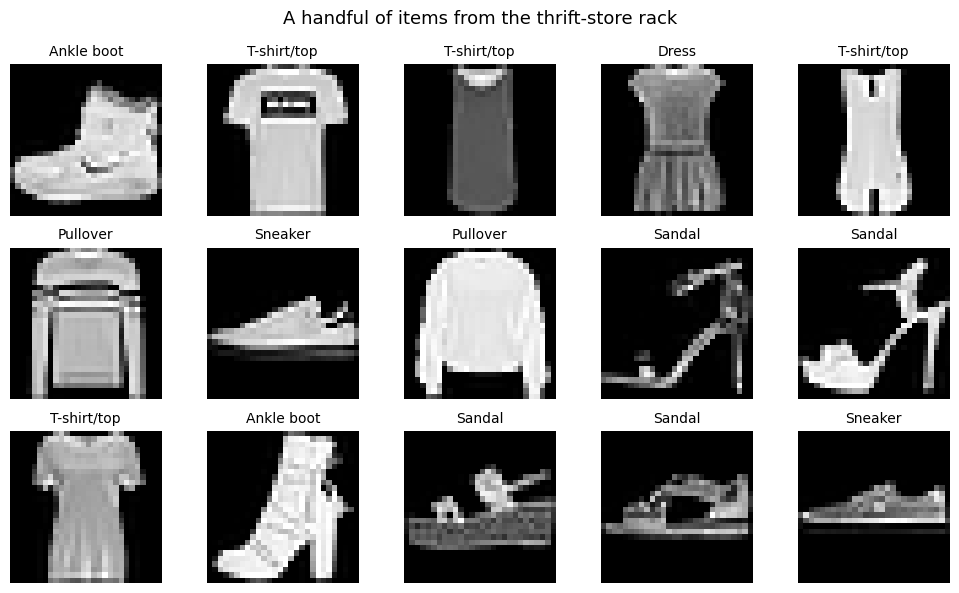

In [4]:
# Show the first 15 photos from the training pile, with the label a human assigned.
plt.figure(figsize=(10, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')   # draw the actual photo
    plt.title(class_names[train_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle("A handful of items from the thrift-store rack", fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — Prep the raw materials

Before the assembly line starts, we standardize what arrives at the factory door.

Right now each pixel is a number from **0 (black) to 255 (white)**. Networks learn more smoothly when those numbers are small and consistent, so we squeeze every pixel into the range **0 to 1** by dividing by 255. Same picture — just measured on a tidier scale. It's the equivalent of making sure every donated item is unfolded and facing the same way before a worker inspects it.

In [5]:
# Scale pixel values from 0-255 down to 0-1. (Same images, friendlier numbers.)
train_images = train_images / 255.0
test_images  = test_images  / 255.0

print("Done. Pixel values now run from", train_images.min(), "to", train_images.max())

Done. Pixel values now run from 0.0 to 1.0


## Step 6 — Open the black box: the assembly line

Here's the heart of it. **Deep learning just means more hidden layers.** Picture an **assembly line**, where each worker has one small job:

| Stage | In the factory | In the network |
|---|---|---|
| **Input layer** | Raw material — a photo of a donated jacket arrives | The 28×28 pixels enter |
| **Hidden layers** | Worker 1 finds edges. Worker 2, fabric texture. Worker 3, shapes — a collar, a zipper. **More layers = more nuance.** | The network finds patterns, then patterns-of-patterns |
| **Output layer** | The listing label the store can use: *"Vintage denim jacket."* | One of the 10 categories |

> **A shallow network confuses a coat with a shirt. Depth is what lets the computer tell a cardigan from a pullover.**

<div style="border-left:4px solid #C99700;padding:8px 14px;background:#FBF7EC;">
<b>Where the GPU comes in:</b> a few workers (a <i>shallow</i> network) run fine on an ordinary processor. But stack up many layers (a <i>deep</i> network) and you're doing thousands of calculations at once — without the right hardware, that takes <b>hours instead of seconds</b>. That's the chip Colab hands you for free.
</div>

The next cell builds our line. We'll start **shallow** — one worker station — so we have a baseline to improve on later.

In [6]:
# Build the assembly line, one station at a time.
model = keras.Sequential([

    # INPUT — each photo arrives as a 28x28 grid (the raw material at the factory door)
    keras.layers.Input(shape=(28, 28)),

    # FLATTEN — unfold that grid into a single row of 784 pixels so the workers can scan it
    keras.layers.Flatten(),

    # HIDDEN — one worker station with 128 workers, each looking for a pattern.
    #          (We'll add MORE stations later to see what depth does.)
    keras.layers.Dense(128, activation='relu'),

    # OUTPUT — 10 bins, one per clothing category. The network's best guess comes out here.
    keras.layers.Dense(10, activation='softmax')
])

print("Assembly line built: 1 hidden station (a shallow network).")

Assembly line built: 1 hidden station (a shallow network).


In [7]:
# Tell the line HOW to learn from its mistakes, then print the blueprint.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()   # the factory blueprint on one screen

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train it: let the line practice

"Training" sounds mysterious; it's really just **practice with feedback.** The network looks at a batch of clothing, guesses the labels, checks how wrong it was, and nudges its workers to do a little better. One full pass through the training pile is called an **epoch**. We'll run a few.

Watch the `accuracy` number climb with each epoch — that's the line getting better at its job, live, in front of you.

In [8]:
# Train for 10 epochs (10 practice passes). This runs on the cloud machine,
# so the laptop in front of you doesn't have to be powerful.
EPOCHS = 10

history = model.fit(
    train_images, train_labels,
    epochs=EPOCHS,
    validation_data=(test_images, test_labels),  # check against unseen photos as it goes
    verbose=2
)

Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.8251 - loss: 0.5006 - val_accuracy: 0.8511 - val_loss: 0.4074
Epoch 2/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8654 - loss: 0.3753 - val_accuracy: 0.8532 - val_loss: 0.3948
Epoch 3/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8782 - loss: 0.3347 - val_accuracy: 0.8572 - val_loss: 0.4103
Epoch 4/10
1875/1875 - 6s - 3ms/step - accuracy: 0.8856 - loss: 0.3111 - val_accuracy: 0.8666 - val_loss: 0.3662
Epoch 5/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8900 - loss: 0.2962 - val_accuracy: 0.8660 - val_loss: 0.3774
Epoch 6/10
1875/1875 - 6s - 3ms/step - accuracy: 0.8968 - loss: 0.2806 - val_accuracy: 0.8756 - val_loss: 0.3468
Epoch 7/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8997 - loss: 0.2677 - val_accuracy: 0.8732 - val_loss: 0.3459
Epoch 8/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9034 - loss: 0.2581 - val_accuracy: 0.8843 - val_loss: 0.3325
Epoch 9/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9068 - loss: 0.2476 - val_accuracy: 0.8797 - 

## Step 8 — Did it actually learn?

Numbers scrolling by are hard to feel. A picture isn't. We'll plot two things across the epochs:

- **Accuracy** — should climb (the line getting better).
- **Loss** — a measure of "how wrong"; should fall.

The two lines on each chart are the **training pile** vs. the **unseen test pile**. When they track closely, the network is genuinely learning to sort clothes — not just memorizing the ones it's seen.

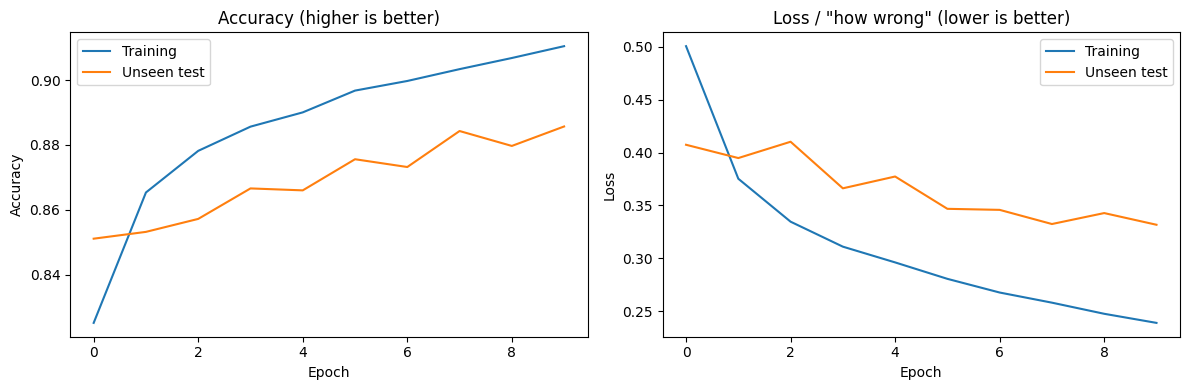

In [9]:
# Plot accuracy and loss so we can SEE the learning, not just read it.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Unseen test')
ax1.set_title('Accuracy (higher is better)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Unseen test')
ax2.set_title('Loss / "how wrong" (lower is better)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()

plt.tight_layout()
plt.show()

## Step 9 — The payoff: watch it sort clothes it's never seen

Now the real test. We hand the network photos from the **test pile** — items it was never trained on — and let it assign a label, just like a worker pulling from a fresh donation bin.

Below, each photo shows the network's guess and its confidence. **Green** means it matched the human label; **red** means it missed. Even a few misses are worth a look — they're usually the genuinely tricky ones (is that a coat or a pullover?), which is exactly the confusion that *depth* helps resolve.

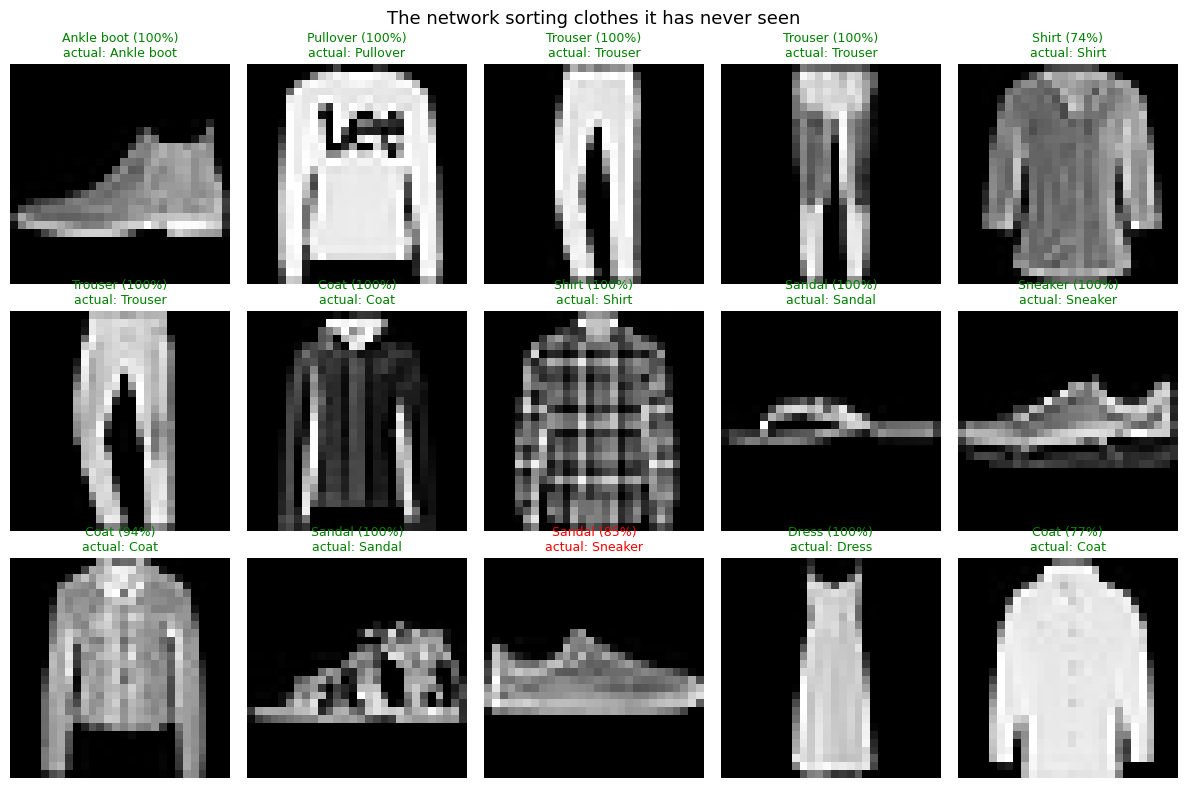

In [10]:
# Ask the trained network to label 15 unseen photos, and color-code right vs. wrong.
predictions = model.predict(test_images, verbose=0)

plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(test_images[i], cmap='gray')
    plt.axis('off')

    guess      = np.argmax(predictions[i])       # the network's pick
    confidence = 100 * np.max(predictions[i])    # how sure it is
    truth      = test_labels[i]                  # the correct answer

    color = 'green' if guess == truth else 'red'
    plt.title(f"{class_names[guess]} ({confidence:.0f}%)\nactual: {class_names[truth]}",
              color=color, fontsize=9)

plt.suptitle("The network sorting clothes it has never seen", fontsize=13)
plt.tight_layout()
plt.show()

## Step 10 — From *user* to *understander*: change one number

This is the moment that matters. A user takes the output as given. An **understander** asks *"what happens if I change something?"* — and then finds out.

Our network so far is **shallow**: one worker station. The deck's claim was that **depth** is what lets a computer tell a cardigan from a pullover. Let's test it ourselves.

<div style="border-left:4px solid #C99700;padding:10px 14px;background:#FBF7EC;">
<b>Predict first, then run.</b> Before you run the next cell, make a guess: will adding more worker stations make it <i>more</i> accurate, <i>less</i> accurate, or about the same? Write your guess down. Then change the one line at the top of the cell and run it.
</div>

The cell below is self-contained: it builds a fresh line with however many stations you choose, trains it, and reports the result — so you can edit one line and re-run it as many times as you like.

In [13]:
# ════════════════════════════════════════════════════════════════════
#  👇  TWEAK ME — change ONLY this one line, then run the whole cell.
# ════════════════════════════════════════════════════════════════════
HIDDEN_LAYERS = [228]                 # shallow: ONE worker station (our baseline)
# HIDDEN_LAYERS = [128, 64]           # deeper:  TWO stations
# HIDDEN_LAYERS = [256, 128, 64]      # deepest: THREE stations
# ════════════════════════════════════════════════════════════════════
# (Remove the # in front of a different line to switch which one is active.)

# --- Build a fresh assembly line with the stations you chose above ---
layers = [keras.layers.Input(shape=(28, 28)), keras.layers.Flatten()]
for workers in HIDDEN_LAYERS:                       # add one hidden station per number in the list
    layers.append(keras.layers.Dense(workers, activation='relu'))
layers.append(keras.layers.Dense(10, activation='softmax'))

tweaked_model = keras.Sequential(layers)
tweaked_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print(f"Built a network with {len(HIDDEN_LAYERS)} hidden station(s): {HIDDEN_LAYERS}")
print("Training... (watch the accuracy)")

tweaked_history = tweaked_model.fit(
    train_images, train_labels,
    epochs=10,
    validation_data=(test_images, test_labels),
    verbose=2
)

# --- Report the score on the unseen test pile ---
final_acc = tweaked_history.history['val_accuracy'][-1]
print(f"\n📊 Final accuracy on UNSEEN clothes: {final_acc*100:.1f}%")
print("   Run this cell again with a different HIDDEN_LAYERS line and compare!")

Built a network with 1 hidden station(s): [228]
Training... (watch the accuracy)
Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.8293 - loss: 0.4849 - val_accuracy: 0.8372 - val_loss: 0.4371
Epoch 2/10
1875/1875 - 8s - 4ms/step - accuracy: 0.8673 - loss: 0.3643 - val_accuracy: 0.8668 - val_loss: 0.3705
Epoch 3/10
1875/1875 - 6s - 3ms/step - accuracy: 0.8809 - loss: 0.3238 - val_accuracy: 0.8702 - val_loss: 0.3543
Epoch 4/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8894 - loss: 0.3002 - val_accuracy: 0.8744 - val_loss: 0.3570
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.8935 - loss: 0.2849 - val_accuracy: 0.8764 - val_loss: 0.3449
Epoch 6/10
1875/1875 - 5s - 3ms/step - accuracy: 0.8993 - loss: 0.2704 - val_accuracy: 0.8716 - val_loss: 0.3654
Epoch 7/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9045 - loss: 0.2561 - val_accuracy: 0.8846 - val_loss: 0.3306
Epoch 8/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9079 - loss: 0.2460 - val_accuracy: 0.8848 - val_loss: 0.3335
Epoch 9/10
1875

## What just happened

You didn't *use* an AI today. You **built one** — and you watched every part of it:

- **The data** — you put the actual clothing on screen, not a text reply.
- **The logic** — you saw the assembly line: input, hidden layers, output, and how depth changes the result.
- **The hardware** — you toggled on a GPU, and AI stopped being magic. It became a physical process — real compute, real energy.

<div style="background:#00694E;padding:18px 20px;border-radius:8px;color:#ffffff;">
Every line of this ran in a browser tab — the same way on a \$200 Chromebook as on a research workstation. <b>The device stopped deciding who gets to learn.</b> That's the equalizer: a student in Appalachian Ohio or the Mississippi Delta gets the same chip, the same data, the same shot at understanding.
</div>

The most powerful AI doesn't need a warehouse to run. It needs good data, clear purpose, and someone who understands how to build it — and that person can come from anywhere.

## Keep it: save to GitHub & take it home

**To save your own copy to GitHub:**
**File → Save a copy in GitHub** → pick your repository → Colab writes the notebook straight to it. (You'll authorize Colab the first time.) That copy keeps every code cell *and* every note, so a student can reopen it and run it anywhere.

You can also do **File → Download → Download .ipynb** for a local copy, or **File → Save a copy in Drive**.

---

### Resources

- **Fork the real course notebooks:** [github.com/TMPenwell/MIS2800-repo-to-share-with-others](https://github.com/TMPenwell/MIS2800-repo-to-share-with-others)
- **Step-by-step Colab how-to guides (Scribe):** scribehow.com → *Google Colab*
- **Get in touch:** penwellt@ohio.edu · penwellt@bytesandbits.org

<div style="color:#555;font-size:13px;margin-top:14px;">
Tasha Penwell, MISM · Assistant Professor of Instruction, Ohio University · Founder, Bytes &amp; Bits<br>
Closing the Rural Digital Divide with Google Colab · Southern Spark 2026
</div>